## 1. Data Loading, EDA



In [58]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import json

In [59]:
df = pd.read_csv("tmdb_5000_movies.csv")
df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [61]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


The cell above shows some 0 values which are missing values disguised as 0s, these values have to be taken care of to get accurate results

In [62]:
#Checking the number of 0 (missing) values in each column
print("Number of missing values in budget and revenue")
print("Budget = 0:", (df["budget"] == 0).sum())
print("Revenue = 0:", (df["revenue"] == 0).sum())
#Calculating the percentage of movies these values affect
print("Percentage of movies affected by missing values in budget and revenue")
print(f"Budget = 0: {(df["budget"] == 0).sum() / len(df) * 100:.1f}% of movies")
print(f"Revenue = 0: {(df["revenue"] == 0).sum() / len(df) * 100:.1f}% of movies")

Number of missing values in budget and revenue
Budget = 0: 1037
Revenue = 0: 1427
Percentage of movies affected by missing values in budget and revenue
Budget = 0: 21.6% of movies
Revenue = 0: 29.7% of movies


In [63]:
#Checking the missing values from df.info() more clearly
df.isnull().sum()[df.isnull().sum() > 0]

,0
homepage,3091
overview,3
release_date,1
runtime,2
tagline,844


In [64]:
#Checking for duplicates
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate titles:", df["title"].duplicated().sum())

Duplicate rows: 0
Duplicate titles: 3


In [65]:
#Looking at the JSON-encoded columns
print(df["genres"].iloc[0])

[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]


## Outcomes of EDA:
- 4083 movies, 20 columns
- Budget and Revenue columns contain missing values, missing values in budget affect 21.6% of the data and missing values in revenue affects 29.7% of the data
- Significant amount of missing values found in homepage and tagline
- Genres, keywords and production companies categories are stored as JSON strings which have to be parsed
- No duplicate rows, 3 duplicate titles

## 2. Data Cleaning

In [66]:
#Dropping columns which are not required
df = df.drop(columns = ["homepage", "tagline", "keywords", "spoken_languages", "production_companies", "production_countries", "status", "original_language", "original_title", "id"])
print(f"New shape: {df.shape}")
print(f"Remaining columns: {df.columns.tolist()}")

New shape: (4803, 10)
Remaining columns: ['budget', 'genres', 'overview', 'popularity', 'release_date', 'revenue', 'runtime', 'title', 'vote_average', 'vote_count']


In [67]:
#Replacing 0s for missing values with NaN so they can still be analysed
df["budget"] = df["budget"].replace(0,np.nan)
print(df["budget"].isna().sum()) #checking if all 0s were correctly replaced, if the replacement has been done right then this sum should equal the number of 0s found in the budget column (1037) earlier
#Repeating same process for revenue
df["revenue"] = df["revenue"].replace(0,np.nan)
print(df["revenue"].isna().sum()) #should be 1427 if done right

1037
1427


In [68]:
#JSON parsing
df["genres"] = df["genres"].apply(lambda x: [d["name"] for d in json.loads(x)]) #a lambda function to loop through every row and extract the list of genre name(s) from each JSON "dictionary"
df["genres"].head()

,genres
0,"[Action, Adventure, Fantasy, Science Fiction]"
1,"[Adventure, Fantasy, Action]"
2,"[Action, Adventure, Crime]"
3,"[Action, Crime, Drama, Thriller]"
4,"[Action, Adventure, Science Fiction]"


In [69]:
#Converting the release_date column to standard date time format as they are currently stored in YYYY-MM-DD format but as strings
df["release_date"] = pd.to_datetime(df["release_date"])
#Extracting the year as a new column (needed later on)
df["Release_Year"] = df["release_date"].dt.year
#Dropping rows with missing release date, minimal in number, easier to just drop than to deal with
df = df.dropna(subset = ["release_date"])
print(df.shape) #previous shape was 4803 x 11, new shape should be 4802 x 11 as there is only one row with missing value in release date
#Dropping 2 rows of runtime as well as they contain missing values
df = df.dropna(subset = ["runtime"])
print(df.shape) #new shape should be 4800 x 11

(4802, 11)
(4800, 11)


## Summary of data cleaning
- Dropped 10 columns which are not required
- Replaced zeroes 1037 rows in the "budget" column and 1427 rows in "revenue" NaN (proper missing value notation) to avoid skewing calculations
- Parsen JSON based data into regular python lists
- Converted datatype of "release_date" column from string based dates to standard date-time format
- Dropped 1 row in "release_date" column and 2 rows in "runtime" column as they contained missing values
- Final shape of dataframe: 4800 x 11

## 3. Univariate Analysis

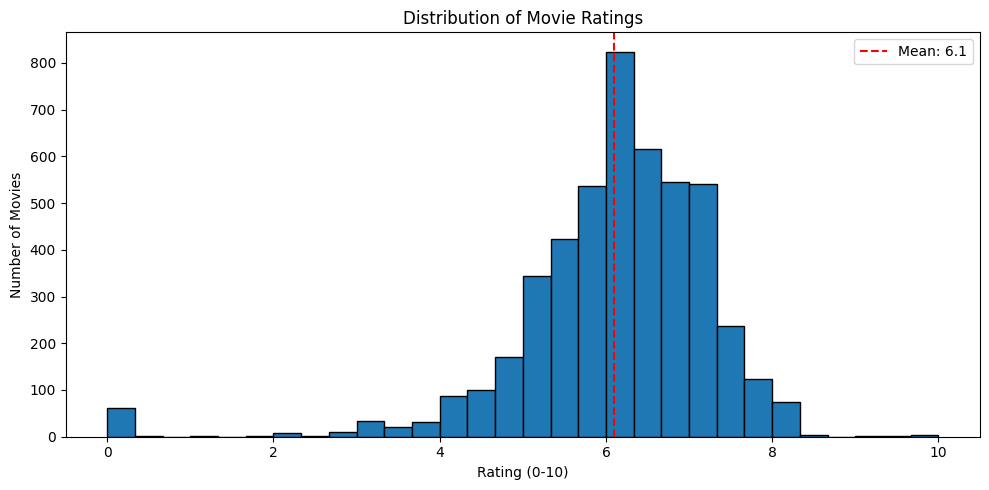

In [70]:
#Plotting frequency of movie ratings
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["vote_average"], bins=30, edgecolor="black")
ax.set_title("Distribution of Movie Ratings")
ax.set_xlabel("Rating (0-10)")
ax.set_ylabel("Number of Movies")
ax.axvline(df["vote_average"].mean(), color="red", linestyle="--", label=f"Mean: {df['vote_average'].mean():.1f}")
ax.legend()
plt.tight_layout()
plt.show()

In [71]:
#Noticed an anomaly in movies rated 0, diving further into it
zero_rated = df[df["vote_average"] == 0]
print(f"Number of movies with rating 0: {len(zero_rated)}")
print(f"\nTheir vote counts:")
print(zero_rated["vote_count"].describe())
print(f"\nSample titles:")
print(zero_rated[["title", "vote_average", "vote_count"]].head(10))

Number of movies with rating 0: 61

Their vote counts:
count    61.000000
mean      0.016393
std       0.128037
min       0.000000
25%       0.000000
50%       0.000000
75%       0.000000
max       1.000000
Name: vote_count, dtype: float64

Sample titles:
                     title  vote_average  vote_count
1464   Black Water Transit           0.0           0
3669  Should've Been Romeo           0.0           0
3670       Running Forever           0.0           0
3852            The Secret           0.0           0
3855        Time to Choose           0.0           0
3960          The Deported           0.0           0
3967   Four Single Fathers           0.0           0
4051                8 Days           0.0           0
4065            Mi America           0.0           0
4068             Sharkskin           0.0           0


From the results above, it is clear that there are a lot of movies rated 0 with 0 votes which just means that the data is actually missing and the 0s are just placeholders for the missing data

In [72]:
#Upon further inspection, also noticed that there are a lot of movies with low number of votes (<10) which could skew the final output as <10 votes is a very small sample size
#Thus finding the count and percentage of movies with <10 votes
print("Movies with fewer than 10 votes:")
print(f"  Count: {(df['vote_count'] < 10).sum()}")
print(f"  Percentage: {(df['vote_count'] < 10).sum() / len(df) * 100:.1f}%")

Movies with fewer than 10 votes:
  Count: 409
  Percentage: 8.5%


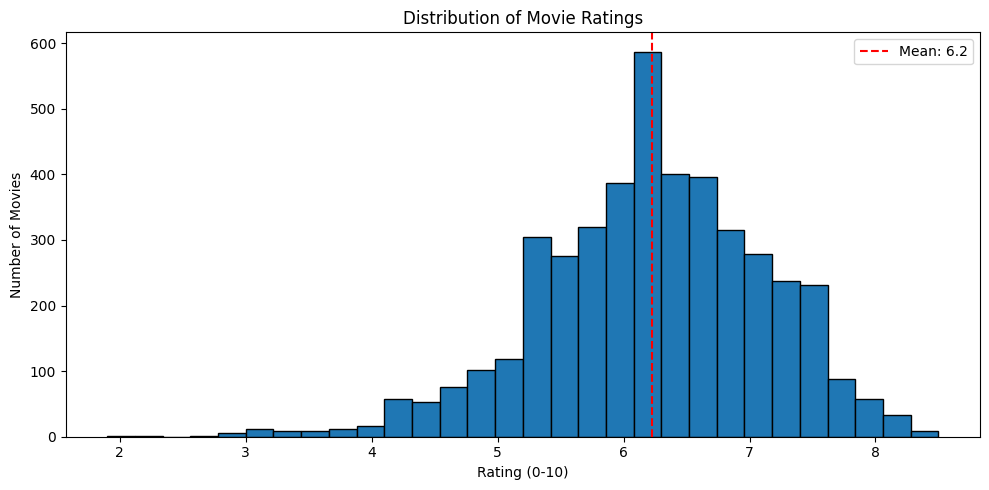

In [73]:
#Since there are actual missing values as well as unreliable data (movies with low vote counts), treat both actual missing values as well as unreliable data as missing values and replace them with NaN
df.loc[df["vote_count"] < 10, "vote_average"] = np.nan
#New reveiw distribution
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["vote_average"], bins=30, edgecolor="black")
ax.set_title("Distribution of Movie Ratings")
ax.set_xlabel("Rating (0-10)")
ax.set_ylabel("Number of Movies")
ax.axvline(df["vote_average"].mean(), color="red", linestyle="--", label=f"Mean: {df['vote_average'].mean():.1f}")
ax.legend()
plt.tight_layout()
plt.show()

The bar corresponding to "0" ratings has been removed which means that the missing data was dealt with properly and the new mean is different to the previous value and is more reliable

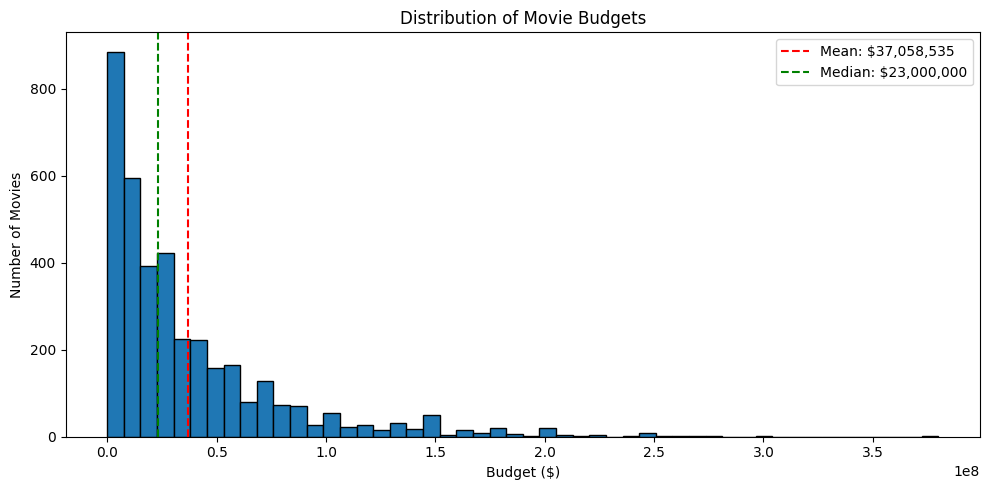

In [74]:
#Budget distribution, red line represents mean, green line represents median
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["budget"].dropna(), bins=50, edgecolor="black")
ax.set_title("Distribution of Movie Budgets")
ax.set_xlabel("Budget ($)")
ax.set_ylabel("Number of Movies")
ax.axvline(df["budget"].mean(), color="red", linestyle="--", label=f"Mean: ${df['budget'].mean():,.0f}")
ax.axvline(df["budget"].median(), color="green", linestyle="--", label=f"Median: ${df['budget'].median():,.0f}")
ax.legend()
plt.tight_layout()
plt.show()

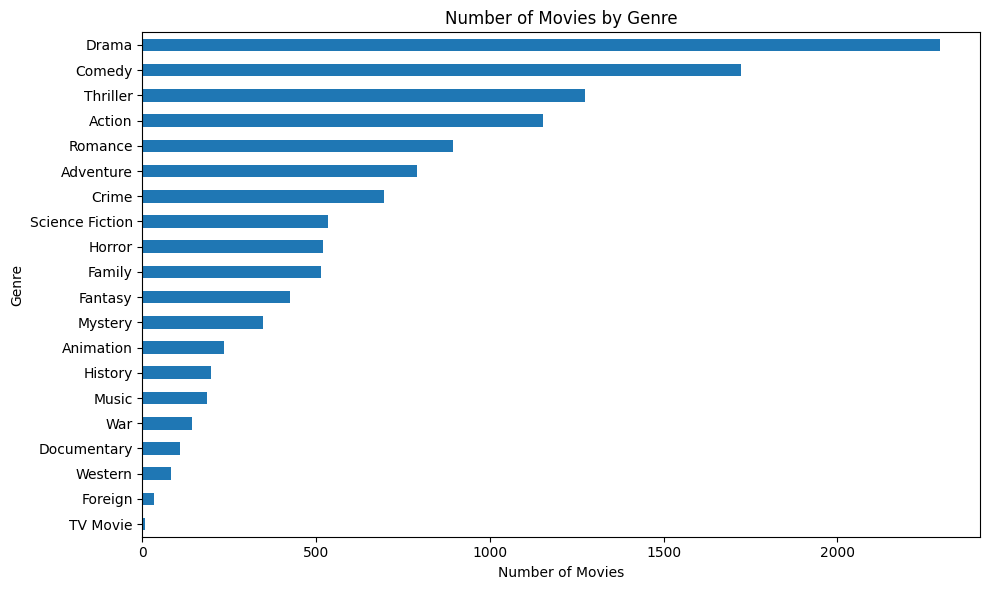

In [75]:
#Visualising genre frequency to analyse and see which genre of movies are the most common
genre_counts = df["genres"].explode().value_counts() #separating each genre into its own column

fig, ax = plt.subplots(figsize=(10, 6))
genre_counts.plot(kind="barh", ax=ax)
ax.set_title("Number of Movies by Genre")
ax.set_xlabel("Number of Movies")
ax.set_ylabel("Genre")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

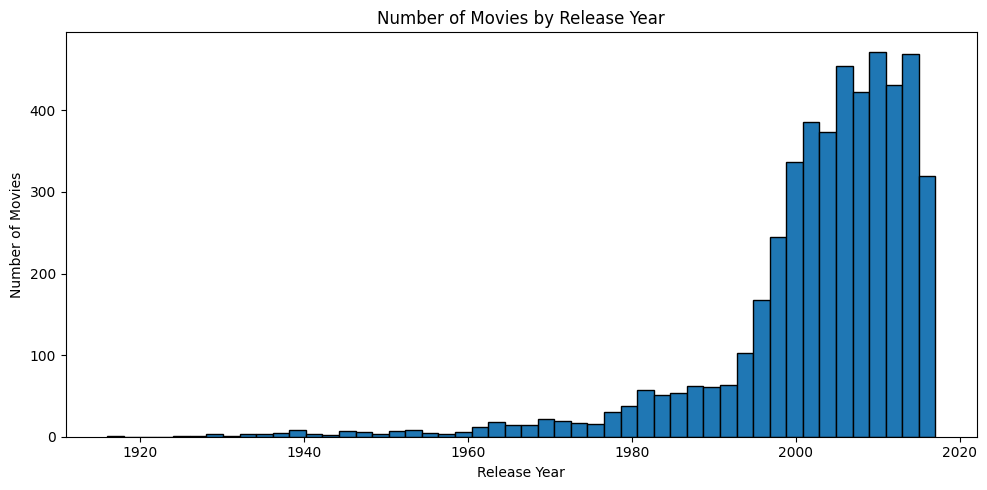

In [78]:
#A release dates plot to see what time periods the dataset covers
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["Release_Year"].dropna(), bins=50, edgecolor="black")
ax.set_title("Number of Movies by Release Year")
ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Movies")
plt.tight_layout()
plt.show()

## Results of Univariate Analysis
- Removed missing data and unreliable data from ratings
- Ratings distribution follows a slightly left skewed bell curve with a mean of 6.1
- Budget distribution is highly right skewed with a median of \$23,000,000 and mean of \$37,058,535
- Top 3 genres are Drama, Thriller and Comedy with Drama containing 2000+ movies
- Dataset is concentrated with movies from 2000-2017 with minimal representation of movies before 1980
